In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from matplotlib import pyplot as plt
import re

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [5]:
data = pd.read_csv("Titanic.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [58]:
df = data.copy()
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna('S', inplace=True)
df.isnull().sum()
# df.head()

C:\Users\kysoc\AppData\Local\Temp\ipykernel_27124\1084923877.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\kysoc\AppData\Local\Temp\ipykernel_27124\1084923877.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignme

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

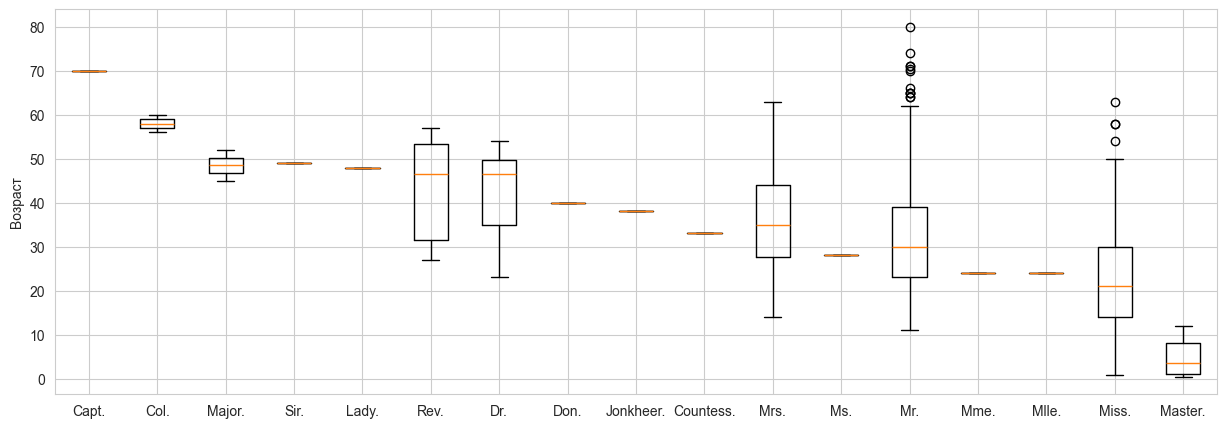

In [60]:
titles = ("Capt.", "Col.", "Major.", "Sir.", "Lady.", "Rev.", "Dr.", "Don.", \
         "Jonkheer.", "Countess.", "Mrs.", "Ms.", "Mr.", "Mme.", "Mlle.", "Miss.", "Master.")

titled_names = []
for name in data.Name:
    for title in titles:
        if title in name.split(" "):
            titled_names.append(title)
            break

# data.insert(12, "Title", titled_names)

ages = dict.fromkeys(titles, [])
for i, title in enumerate(data.Title):
    if not pd.isna(data.Age[i]):
        ages[title] = ages[title] + [data.Age[i]]

fig, ax = plt.subplots(figsize=(15, 5))
ax.boxplot(ages.values(), tick_labels=titles, vert=True)
ax.set_ylabel("Возраст")
plt.show()

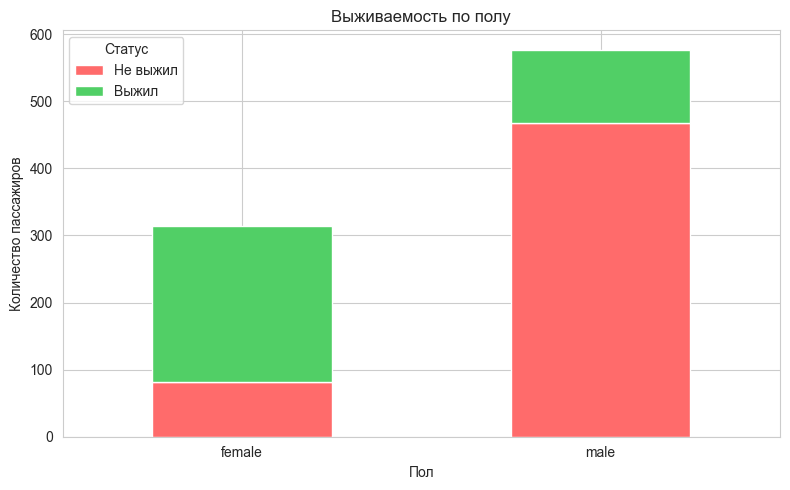


Процент выживших:
Sex
female    74.20
male      18.89%


In [ ]:
gender_survival = df.groupby(["Sex", "Survived"]).size().unstack(fill_value=0)
gender_survival.columns = ["Не выжил", "Выжил"]

plt.figure(figsize=(8, 5))
gender_survival.plot(kind="bar", stacked=True, ax=plt.gca(), color=["#ff6b6b", "#51cf66"])
plt.title("Выживаемость по полу")
plt.ylabel("Количество пассажиров")
plt.xlabel("Пол")
plt.xticks(rotation=0)
plt.legend(title="Статус")
plt.tight_layout()
plt.show()

survival_rate_gender = df.groupby("Sex")["Survived"].mean() * 100
print(f"\nПроцент выживших:\n{survival_rate_gender.round(2).to_string()}%")

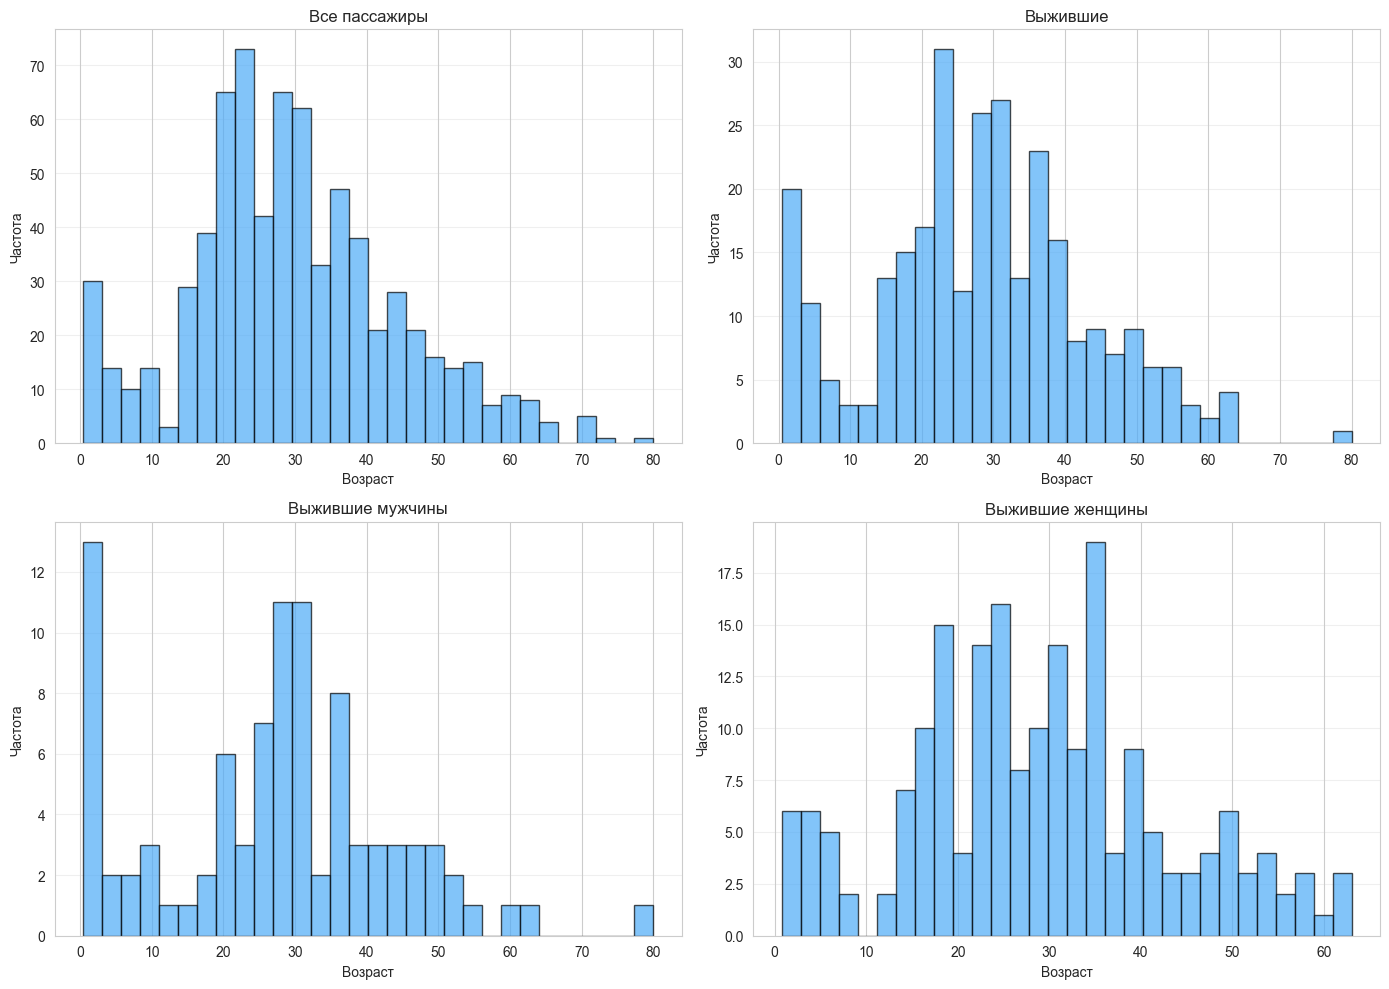

In [62]:
age_plots_data = {
    "Все пассажиры": df["Age"],
    "Выжившие": df[df["Survived"] == 1]["Age"],
    "Выжившие мужчины": df[(df["Survived"] == 1) & (df["Sex"] == "male")]["Age"],
    "Выжившие женщины": df[(df["Survived"] == 1) & (df["Sex"] == "female")]["Age"]
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (title, series) in enumerate(age_plots_data.items()):
    axes[idx].hist(series.dropna(), bins=30, edgecolor="black", alpha=0.7, color="#4dabf7")
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Возраст")
    axes[idx].set_ylabel("Частота")
    axes[idx].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
minors = df.query("Age > 0 and Age < 18").copy()

survival_stats = minors["Survived"].agg(
    total_count="count",
    survived_count="sum",
    survival_rate="mean"
)

print(f"Общее количество: {int(survival_stats['total_count'])}")
print(f"Выживших: {int(survival_stats['survived_count'])}")
print(f"Процент выживших: {survival_stats['survival_rate'] * 100:.2f}%")

Общее количество: 113
Выживших: 61
Процент выживших: 53.98%


In [41]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

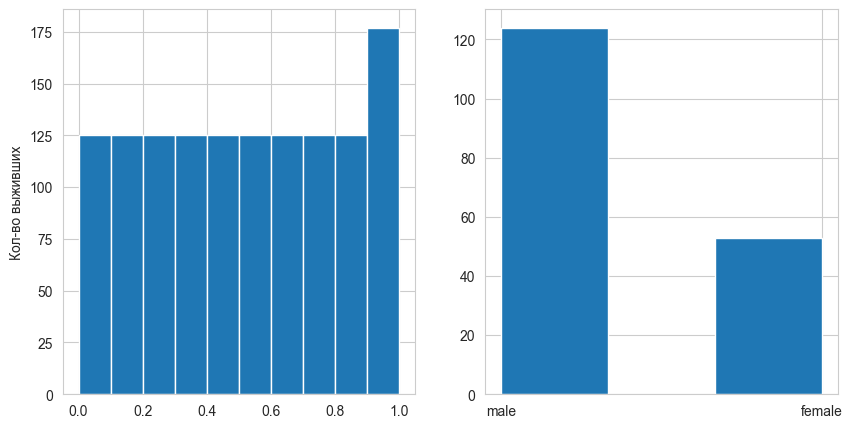

In [42]:
noage = data.loc[(pd.isna(data["Age"]))]
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(noage.Survived, bins=10, cumulative=1)
ax[1].hist(noage.Sex, bins=3)
ax[0].set_ylabel("Кол-во выживших")
plt.show()

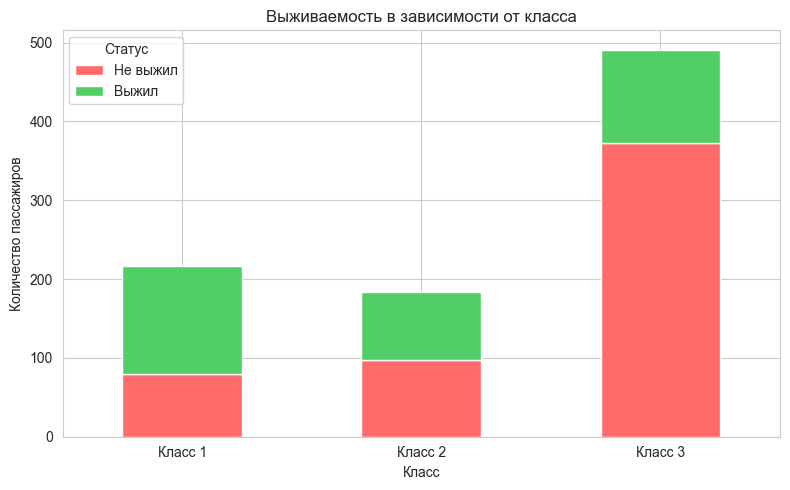


Процент выживших по классам:
Pclass
1    62.96
2    47.28
3    24.24%


In [86]:
class_survival = df.groupby(["Pclass", "Survived"]).size().unstack(fill_value=0)
class_survival.columns = ["Не выжил", "Выжил"]
class_survival.index = [f"Класс {i}" for i in class_survival.index]

plt.figure(figsize=(8, 5))
class_survival.plot(kind="bar", stacked=True, ax=plt.gca(), color=["#ff6b6b", "#51cf66"])
plt.title("Выживаемость в зависимости от класса")
plt.ylabel("Количество пассажиров")
plt.xlabel("Класс")
plt.xticks(rotation=0)
plt.legend(title="Статус")
plt.tight_layout()
plt.show()

class_survival_rate = df.groupby("Pclass")["Survived"].mean() * 100
print(f"\nПроцент выживших по классам:\n{class_survival_rate.round(2).to_string()}%")

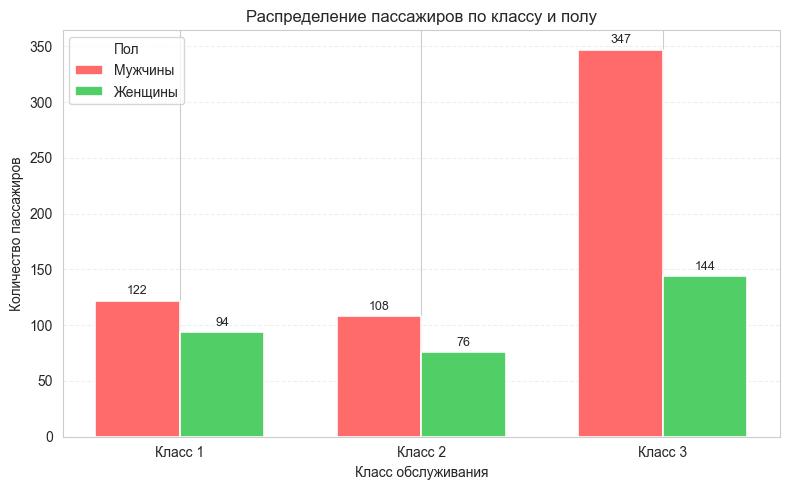

📊 Статистика по классам:
Класс 1: 122 мужчин, 94 женщин (всего: 216)
Класс 2: 108 мужчин, 76 женщин (всего: 184)
Класс 3: 347 мужчин, 144 женщин (всего: 491)


In [ ]:
COLORS = {"male": "#ff6b6b", "female": "#51cf66"}
CLASS_LABELS = ["Класс 1", "Класс 2", "Класс 3"]

passenger_counts = pd.crosstab(df["Pclass"], df["Sex"])

x_pos = np.arange(len(CLASS_LABELS)) 
bar_width = 0.35  

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x_pos - bar_width/2, 
    passenger_counts["male"], 
    width=bar_width, 
    label="Мужчины", 
    color=COLORS["male"],
    edgecolor="white",
    linewidth=1.2
)

ax.bar(
    x_pos + bar_width/2, 
    passenger_counts["female"], 
    width=bar_width, 
    label="Женщины", 
    color=COLORS["female"],
    edgecolor="white",
    linewidth=1.2
)

ax.set_xticks(x_pos)
ax.set_xticklabels(CLASS_LABELS)
ax.set_xlabel("Класс обслуживания")
ax.set_ylabel("Количество пассажиров")
ax.set_title("Распределение пассажиров по классу и полу")
ax.legend(title="Пол")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)  

for idx, count in enumerate(passenger_counts["male"]):
    ax.text(idx - bar_width/2, count + 3, str(count), ha="center", va="bottom", fontsize=9)
for idx, count in enumerate(passenger_counts["female"]):
    ax.text(idx + bar_width/2, count + 3, str(count), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("📊 Статистика по классам:")
for cls in [1, 2, 3]:
    subset = df[df["Pclass"] == cls]
    m = len(subset[subset["Sex"] == "male"])
    f = len(subset[subset["Sex"] == "female"])
    print(f"Класс {cls}: {m} мужчин, {f} женщин (всего: {m+f})")

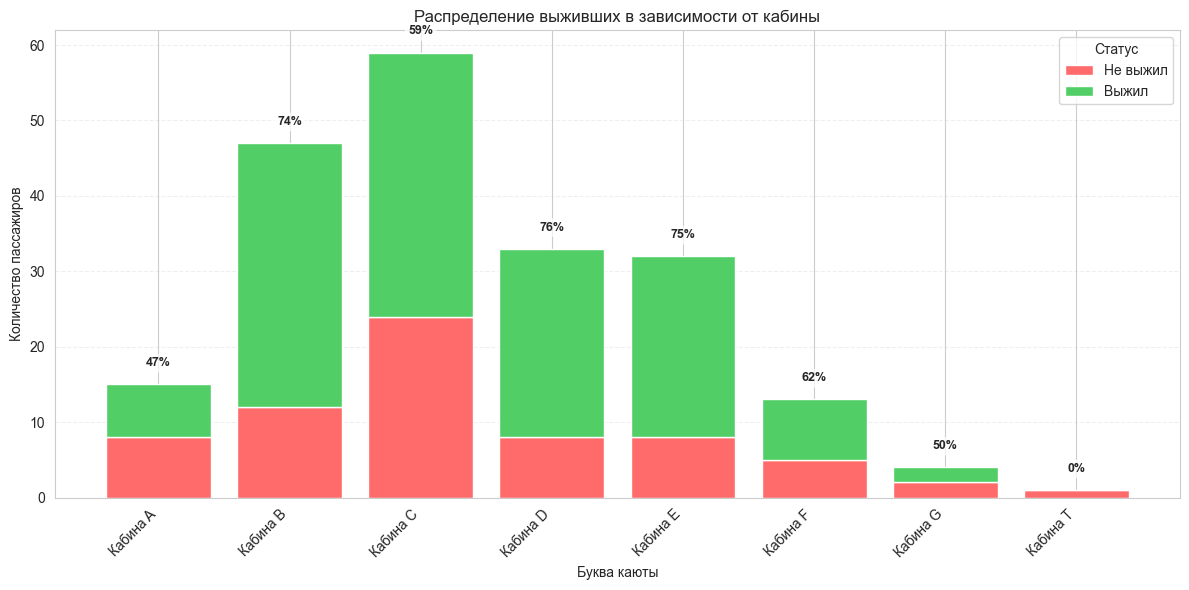

In [90]:
COLORS = {"Выжил": "#51cf66", "Не выжил": "#ff6b6b"}

df["Cabin_Letter"] = df["Cabin"].str.extract(r"^([A-Za-z])", expand=False)
cabin_df = df[df["Cabin_Letter"].notna()].copy()

cabin_stats = (
    cabin_df.groupby(["Cabin_Letter", "Survived"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Не выжил", 1: "Выжил"})
    .reindex(sorted(cabin_df["Cabin_Letter"].unique()), fill_value=0)
)

x_labels = [f"Кабина {letter}" for letter in cabin_stats.index]
x_pos = np.arange(len(x_labels))
bar_width = 0.8

fig, ax = plt.subplots(figsize=(12, 6))

bars_dead = ax.bar(
    x_pos, 
    cabin_stats["Не выжил"], 
    width=bar_width, 
    label="Не выжил", 
    color=COLORS["Не выжил"],
    edgecolor="white",
    linewidth=1
)

bars_alive = ax.bar(
    x_pos, 
    cabin_stats["Выжил"], 
    width=bar_width, 
    bottom=cabin_stats["Не выжил"],  
    label="Выжил", 
    color=COLORS["Выжил"],
    edgecolor="white",
    linewidth=1
)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_xlabel("Буква каюты")
ax.set_ylabel("Количество пассажиров")
ax.set_title("Распределение выживших в зависимости от кабины")
ax.legend(title="Статус")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

for idx, letter in enumerate(cabin_stats.index):
    total = cabin_stats.loc[letter].sum()
    survived = cabin_stats.loc[letter, "Выжил"]
    if total > 0:
        pct = (survived / total) * 100
        ax.text(
            idx, 
            total + 2, 
            f"{pct:.0f}%", 
            ha="center", 
            va="bottom", 
            fontsize=9,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7)
        )

plt.tight_layout()
plt.show()

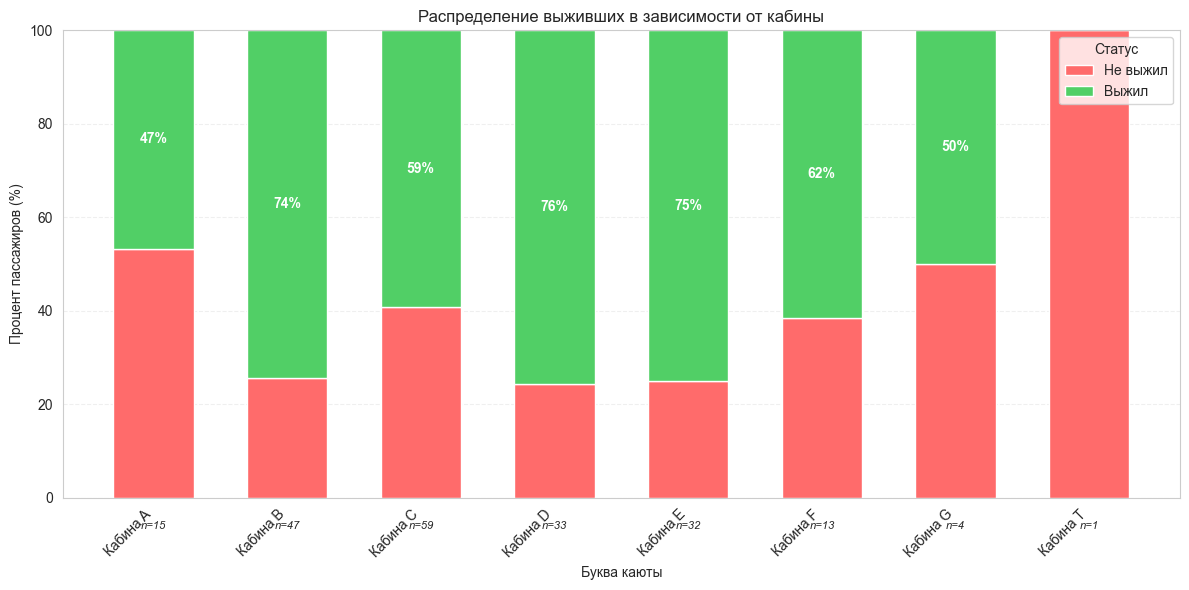

In [93]:
COLORS = {"Выжил": "#51cf66", "Не выжил": "#ff6b6b"}

df["Cabin_Letter"] = df["Cabin"].str.extract(r"^([A-Za-z])", expand=False)
cabin_df = df[df["Cabin_Letter"].notna()].copy()

cabin_stats = (
    cabin_df.groupby(["Cabin_Letter", "Survived"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "Не выжил", 1: "Выжил"})
    .reindex(sorted(cabin_df["Cabin_Letter"].unique()), fill_value=0)
)

cabin_stats["Всего"] = cabin_stats.sum(axis=1)
cabin_stats["% выживших"] = (
    cabin_stats["Выжил"] / cabin_stats["Всего"] * 100
).round(1).where(cabin_stats["Всего"] > 0, 0)

x_labels = [f"Кабина {letter}" for letter in cabin_stats.index]
x_pos = np.arange(len(x_labels))
bar_width = 0.6

fig, ax = plt.subplots(figsize=(12, 6))

bars_dead = ax.bar(
    x_pos, 
    100 - cabin_stats["% выживших"], 
    width=bar_width, 
    label="Не выжил", 
    color=COLORS["Не выжил"],
    edgecolor="white",
    linewidth=1
)

bars_alive = ax.bar(
    x_pos, 
    cabin_stats["% выживших"], 
    width=bar_width, 
    bottom=100 - cabin_stats["% выживших"],
    label="Выжил", 
    color=COLORS["Выжил"],
    edgecolor="white",
    linewidth=1
)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_xlabel("Буква каюты")
ax.set_ylabel("Процент пассажиров (%)")
ax.set_title("Распределение выживших в зависимости от кабины")
ax.legend(title="Статус")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

for idx, pct in enumerate(cabin_stats["% выживших"]):
    if pct > 10: 
        ax.text(
            idx, 
            100 - pct/2, 
            f"{pct:.0f}%", 
            ha="center", 
            va="center", 
            fontsize=10,
            fontweight="bold",
            color="white"
        )

for idx, total in enumerate(cabin_stats["Всего"]):
    ax.text(
        idx, 
        -5, 
        f"n={int(total)}", 
        ha="center", 
        va="top", 
        fontsize=8,
        style="italic"
    )

plt.tight_layout()
plt.show()

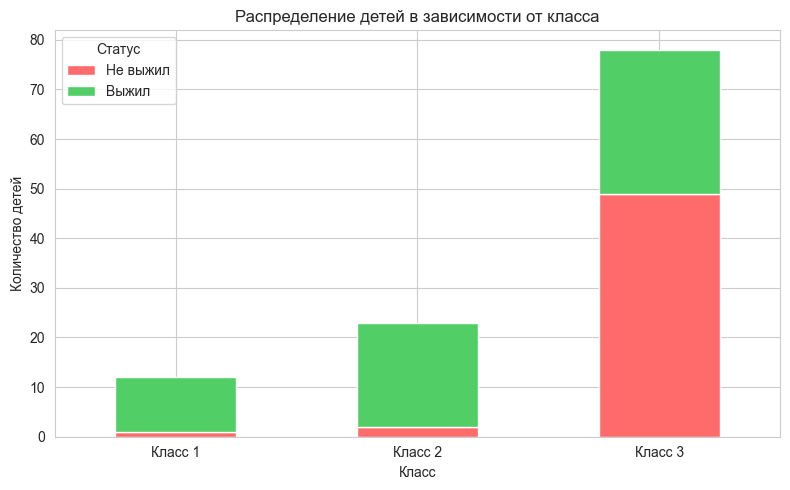

Класс 1: выжило 11/12 детей (91.7%)
Класс 2: выжило 21/23 детей (91.3%)
Класс 3: выжило 29/78 детей (37.2%)


In [ ]:
children_by_class = df[children_mask].groupby(["Pclass", "Survived"]).size().unstack(fill_value=0)
children_by_class.columns = ["Не выжил", "Выжил"]
children_by_class.index = [f"Класс {i}" for i in children_by_class.index]

plt.figure(figsize=(8, 5))
children_by_class.plot(kind="bar", stacked=True, ax=plt.gca(), color=["#ff6b6b", "#51cf66"])
plt.title("Распределение детей в зависимости от класса")
plt.ylabel("Количество детей")
plt.xlabel("Класс")
plt.xticks(rotation=0)
plt.legend(title="Статус")
plt.tight_layout()
plt.show()

for cls in [1, 2, 3]:
    subset = df[(df["Pclass"] == cls) & children_mask]
    if len(subset) > 0:
        rate = subset["Survived"].mean() * 100
        print(f"Класс {cls}: выжило {subset['Survived'].sum()}/{len(subset)} детей ({rate:.1f}%)")